# Trimet Data Project

For our project, we decided to work with Trimet data as it sounded interesting and their developer portal have very good documentation for accessing data.

There were 2 static data: GIS (Geospatial Data) and GFTS Static (General Transit Feed Specification).  The GIS basically provides an outline of the Transit map such as stop locations, route boundaries, garage locations and it mainly contains text files like `stops.txt` `stop_times.txt` which shows how trimet vehicles are planned to move.

The main interesting thing we found that had lots of data was GFTS Realtime.  This logs information on Trimet vehicles in realtime, giving back information like location using longitude and latitude, whether the vehicle is delayed or early and by how many seconds, what its next stop and previous stop is and sometimes it gives an approximate of how full the vehicle is.

We worked with this api and built a collector in python to collect data on vehicles every minute.  We ran the collector program for about 5 week days and 2 weekend days. The data we recieved from the api is formated in json which we converted into a csv.

One challenge we face while collecting data was that we didn't have a dedicated machine to run the python program.  Particularly on Tuesdays and Thursdays, we had to commute to school bringing our computer along but we still did try to run the program while in school to get the most accurate data.




## Data Processing

Trimet provided documentation for an api called [/vehicles](https://developer.trimet.org/ws_docs/vehicle_locations_ws.shtml) showing information on what data is collected for a vehicle in real time

Example Json data for 1 vehicle.  This is collected every minute.
After going through the documents in trimet, we've infered on what the data means

*Every minute, it logs about 400 vehicles during the day and almost none at night.*

```
  {
    "routeColor": "61A744",            // Color for route
    "expires": 1760993085102,          // Used by trimet to ensure data up to date
    "signMessage": "FX2 To Gresham",   // display message
    "serviceDate": 1760943600000,      // What day it's serviced on
    "loadPercentage": 15,              // Estimated passenger load (0–100%)
    "latitude": 45.503744191408664,    
    "nextStopSeq": 8,                  // The number of next scheduled stop (8th stop of the day)
    "source": "vm",                    // How the data was recorded
    "type": "bus",                     // Vehicle type (bus, rail, etc.)
    "blockID": 248,                    // Groups multiple trips into blocks
    "signMessageLong": "FX2 Division To Gresham", // More description for message
    "lastLocID": 3397,                 // Stop ID of the last stop location
    "nextLocID": 13732,                
    "locationInScheduleDay": 49133,    // what time bus should be at a certain stop
    "routeSubType": "BRT",             // Subtype (e.g., Bus Rapid Transit)
    "newTrip": false,                  // true if new it's new trip, always false in data
    "longitude": -122.66883380836836,  
    "direction": 0,                    // Route direction (0, 1)
    "inCongestion": false,             // True if vehicle is stopped in traffic
    "routeNumber": 2,                  
    "bearing": 46,                     // Vehicle’s compass (0-360)
    "garage": "POWELL",                
    "tripID": "15644087",              
    "delay": -112,                     // measured in seconds, positive means early
    "extraBlockID": null,              
    "messageCode": 100,                // relates to message display
    "lastStopSeq": 7,                  // the last stop number in sequence of sstop
    "vehicleID": 4531,                 
    "time": 1760992845102,             // Timestamp when this was recorded by vehicle
    "offRoute": false                  // True if vehicle is off its scheduled route
  }
```



## Creating DataFrame from csv

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/vehicle_positions_full_combined.csv')

## Understanding the data

In [106]:
# format for numbers to not use scientific notation
pd.options.display.float_format = '{:.2f}'.format
df.head(2)

,bearing,blockID,collection_timestamp,delay,direction,expires,extraBlockID,garage,inCongestion,lastLocID,...,routeNumber,routeSubType,serviceDate,signMessage,signMessageLong,source,time,tripID,type,vehicleID
0,200.00,243,1760817789,-1132,0,1760818026912,NaN,POWELL,False,7642.00,...,2,BRT,1760770800000,FX2 To Gresham,FX2 Division To Gresham,vm,1760817786912,15643905,bus,4530
1,269.00,248,1760817789,-499,1,1760818022926,NaN,POWELL,False,14241.00,...,2,BRT,1760770800000,FX2 To Portland,FX2 Division To Portland,vm,1760817782926,15644364,bus,4528


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1467843 entries, 0 to 1467842
Data columns (total 31 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   bearing                1467816 non-null  float64
 1   blockID                1467843 non-null  int64  
 2   collection_timestamp   1467843 non-null  int64  
 3   delay                  1467843 non-null  int64  
 4   direction              1467843 non-null  int64  
 5   expires                1467843 non-null  int64  
 6   extraBlockID           2651 non-null     float64
 7   garage                 1465192 non-null  object 
 8   inCongestion           1149359 non-null  object 
 9   lastLocID              1214279 non-null  float64
 10  lastStopSeq            1214279 non-null  float64
 11  latitude               1467843 non-null  float64
 12  loadPercentage         1011580 non-null  float64
 13  locationInScheduleDay  1467843 non-null  int64  
 14  longitude         

### Data Cleaning and Setting Up

#### Investigate columns to see if information is irrelevant for dropping

Some columns are not straightforward and will need more research to get better understanding.  Potentially could be removed from analyzing if not significant or redundant

#### routeSubType

In [108]:
# Check what RouteSubtype column is:
df['routeSubType'].unique()

array(['BRT', 'Bus', 'Light Rail', 'Shuttle'], dtype=object)

This shows that `routeSubType` gives more specification to vehicle info.  A BRT is "Bus Rapid Transit" and a "Bus" is the smaller old buses both are categorized as `bus` for the `type` column.

#### offRoute

Perhaps we can see if vehicles ever go off route

In [109]:
df['offRoute'].value_counts()

offRoute
False    1460626
True        7217
Name: count, dtype: int64

A small portion goes off route which will be interesting to anlyze later on.

#### Extra Block ID


In [110]:
# count where extraBlockID = blockID
same = (df['extraBlockID'] == df['blockID']).sum()
# count how many extrablocks there are
diff = df['extraBlockID'].notna().sum()

print(f"Extrablock id same as block id: {same}")
print(f"Total extrablock ids : {diff}")


Extrablock id same as block id: 2651
Total extrablock ids : 2651


From the above code, we can see extrablockid and blockid is always the same.  So it might just be redundant information.

Checking more columns if they are relevant

In [111]:
print(df['newTrip'].value_counts())
print(df['offRoute'].value_counts())
print(df['inCongestion'].value_counts())

newTrip
False    1467843
Name: count, dtype: int64
offRoute
False    1460626
True        7217
Name: count, dtype: int64
inCongestion
False    1140500
True        8859
Name: count, dtype: int64


newTrip is always False.

After investigating, we are choosing to drop some columns that might not be used

- expires: used internally to ensure data up to date
- newTrip: likely deprecated since it's always false.  Suppose to show when a bus starts a new trip but maybe our 1 minute interval does not catch it when it was sent.
- serviceDate: redundant, already have that with other columns
- extraBlockID: very rarely used and is always the same as BlockID

There are many other columns in our data sets but as of now we are choosing to keep most of them since they might be of use when building learning models.  If in the future we find more columns irrelevant, they will be removed.

In [112]:
df = df.drop(columns=['expires', 'newTrip', 'serviceDate', 'extraBlockID'])

#### Clean up with Date and Time

The first thing we can do is convert the str objects into date time object and also generate new columns that will help analyzing later on.

Cleaning process:
- Convert `collection_timestamp` and `time` from `str` to `datetime`
- Create `hour` and `day` columns so we can group them later
- Create `delay_minutes` converting `delay` in seconds to minute
- Create an hour decimal so that it can be used to plot as a line graph


In [113]:
df['collection_timestamp'] = pd.to_datetime(df['collection_timestamp'], unit='s', errors='coerce')
df['time'] = pd.to_datetime(df['time'], unit='ms', errors='coerce')

# Get hour of day and the day name
df['hour'] = df['collection_timestamp'].dt.hour
df['day'] = df['collection_timestamp'].dt.day_name()

# Convert delay from seconds to minutes
df['delay_minutes'] = df['delay'] / 60

df['hour_decimal'] = (
    df['collection_timestamp'].dt.hour + 
    df['collection_timestamp'].dt.minute / 60
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1467843 entries, 0 to 1467842
Data columns (total 31 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   bearing                1467816 non-null  float64       
 1   blockID                1467843 non-null  int64         
 2   collection_timestamp   1467843 non-null  datetime64[ns]
 3   delay                  1467843 non-null  int64         
 4   direction              1467843 non-null  int64         
 5   garage                 1465192 non-null  object        
 6   inCongestion           1149359 non-null  object        
 7   lastLocID              1214279 non-null  float64       
 8   lastStopSeq            1214279 non-null  float64       
 9   latitude               1467843 non-null  float64       
 10  loadPercentage         1011580 non-null  float64       
 11  locationInScheduleDay  1467843 non-null  int64         
 12  longitude              14678

### Shuttle Vehicles

While working with the collected data, we learned that there are shuttle ADA (Americans with Disabilities Act) vehicles reported by trimet.  These vechiles report delay values over 2 hours early/late.  So we decided to just remove these early on.

In [114]:
df_shuttles = df[df['routeSubType'] == 'Shuttle']

shuttle_performance = df_shuttles.groupby('routeNumber')['delay_minutes'].agg(['mean', 'std', 'count'])
shuttle_performance = shuttle_performance.sort_values(by='std', ascending=False)

print(shuttle_performance)

             mean   std  count
routeNumber                   
98           8.95 27.37   7562


The standard deviation for shuttle delay is a crazy high number which most certainly will throw off analysis so we will be seperating shuttle buses for now.

In [115]:
# Before removing shuttles:
delay_performance_old = df['delay_minutes'].agg(['mean', 'std', 'count'])
df = df[df['routeSubType'] != 'Shuttle'].copy()
delay_performance = df['delay_minutes'].agg(['mean', 'std', 'count'])



In [116]:
print("Before removing shuttles")
print(delay_performance_old)
print("\nAfter removing shuttles")
print(delay_performance)

Before removing shuttles
mean         -1.83
std           5.54
count   1467843.00
Name: delay_minutes, dtype: float64

After removing shuttles
mean         -1.89
std           5.14
count   1460281.00
Name: delay_minutes, dtype: float64


In [117]:
print(f'std dropped from {delay_performance_old['std']:.2f} to {delay_performance['std']:.2f}')
rows_dropped = delay_performance_old['count'] - delay_performance['count']
print(f'This is from dropping only {rows_dropped} rows out of {delay_performance_old['count']} rows which shows how impactful it is')


std dropped from 5.54 to 5.14
This is from dropping only 7562.0 rows out of 1467843.0 rows which shows how impactful it is


### Seperate out Rail (MAX)

Rail vehicles have different kind of data and are not really affected by rush hour or congestion so it will make sense to seperate them out for better analysis.


In [118]:
# save old df
df_original = df.copy()

# Remove rail vehicles
df = df[df['type'] != 'rail'].copy()

In [119]:
print(f"{(len(df_original) - len(df))} rows filtered out from total of {len(df_original)} rows. ({(len(df_original) - len(df)) / len(df_original) * 100:.2f}% of data)")
print(f"{len(df)} rows remaining.")
print(f"std dropped for delay from {df_original['delay_minutes'].std():.2f} to {df['delay_minutes'].std():.2f}")
print(f"std dropped for load_percentage from {df_original['loadPercentage'].std():.2f} to {df['delay_minutes'].std():.2f}")

318484 rows filtered out from total of 1460281 rows. (21.81% of data)
1141797 rows remaining.
std dropped for delay from 5.14 to 4.49
std dropped for load_percentage from 13.83 to 4.49


### Checking for outliers

In [120]:
print(f'highest delay minutes: {df['delay_minutes'].max():.2f} (early)')
print(f'lowest delay minutes: {df['delay_minutes'].min()} (late)')
print(f'Highest load percentage: {df['loadPercentage'].max():.2f}%')

highest delay minutes: 171.18 (early)
lowest delay minutes: -120.25 (late)
Highest load percentage: 192.00%


These are the main concerning outliers that needs to be addressed.



### Look Into delay column

In [121]:
# Check for bus over 1 hour late or early
cut_off = 60
hour_early = df[df['delay_minutes'] > cut_off]
hour_late = df[df['delay_minutes'] < -cut_off]
bad_load = df[df['loadPercentage'] > 100]
bad_load_rail = df_original[df_original['loadPercentage'] > 100]
print(f'{len(hour_early)} buses over {cut_off} minutes early')
print(f'{len(hour_late)} buses over {cut_off} minutes late')
print(f'{len(bad_load)} buses over 100% load percentage')

43 buses over 60 minutes early
192 buses over 60 minutes late
1210 buses over 100% load percentage


### Over 100 Load Percentage

Load percentage should be 0-100 as a fraction.  Let's investigate why there is over 100 for the max value.

In [122]:
# # Filtering out some columnns
time_info = ['collection_timestamp', 'delay', 'time', 'hour', 'hour_decimal', 'day']
bus_info = ['routeSubType', 'loadPercentage', 'vehicleID', 'signMessage', 'inCongestion']
# load_perc_info = time_info.copy() + bus_info
# bad_load = bad_load[load_perc_info]

Check loadpercentage relationship with vehicleID

In [123]:
highest_load_index = df['loadPercentage'].idxmax()
highest_load = df.loc[highest_load_index, 'vehicleID']

print(f'Highest load percentage vehicle ID: {highest_load}')

Highest load percentage vehicle ID: 3052


Let's analyze the worst load.  Maybe seeing the trend of load percentage we can see if there is any concerning behavior

In [124]:
df_highest_load = df[
    (df['vehicleID'] == highest_load) &
    (df['loadPercentage'] > 70) 
].sort_values('time')
df_highest_load = df_highest_load[time_info + bus_info].copy()
df_highest_load.head(3)

,collection_timestamp,delay,time,hour,hour_decimal,day,routeSubType,loadPercentage,vehicleID,signMessage,inCongestion
1091461,2025-10-22 22:36:47,-389,2025-10-22 22:36:45.146,22,22.60,Wednesday,Bus,71.00,3052,72 To Clackamas Town Ctr,False
1091964,2025-10-22 22:37:48,-369,2025-10-22 22:37:41.348,22,22.62,Wednesday,Bus,73.00,3052,72 To Clackamas Town Ctr,False
1092470,2025-10-22 22:38:48,-224,2025-10-22 22:38:44.740,22,22.63,Wednesday,Bus,73.00,3052,72 To Clackamas Town Ctr,False


In [125]:
df_highest_load['hour'].value_counts()

hour
0     60
23    59
1     56
22    24
Name: count, dtype: int64

The value count of hours strongly suggest that this is a data reporting error rather than actually having over filled bus.  The hour that this occur is around midnight from 10pm to 1 am.

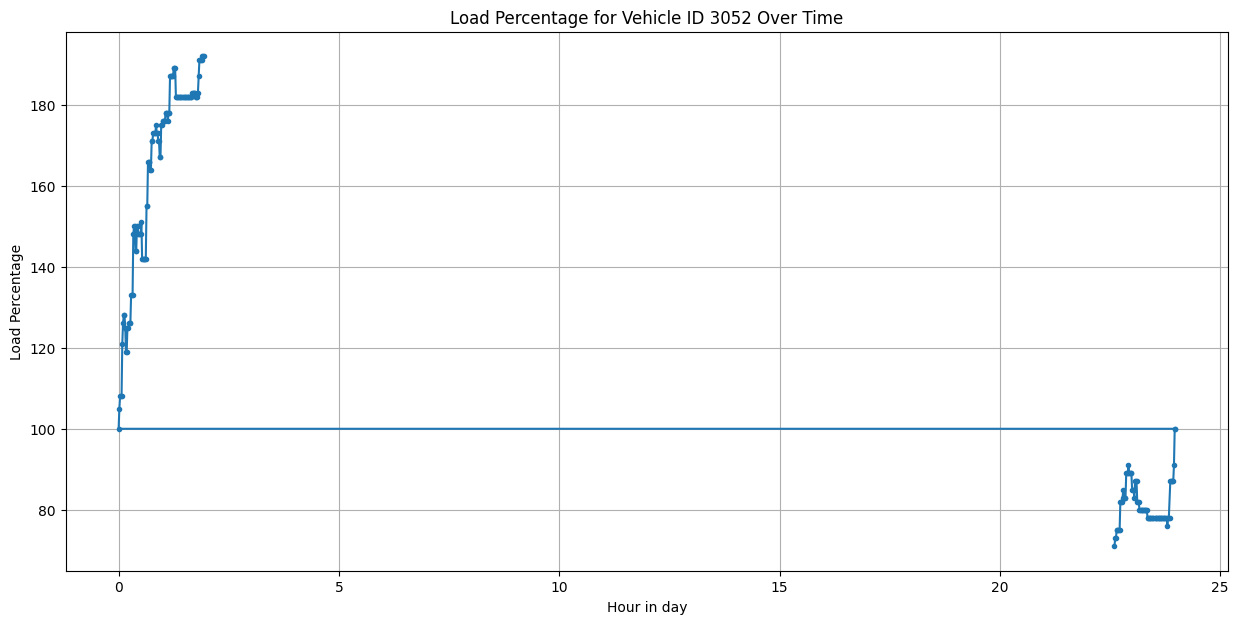

In [126]:
plt.figure(figsize = (15,7))
plt.plot(df_highest_load['hour_decimal'], df_highest_load['loadPercentage'], marker='.', linestyle = '-')
plt.title(f'Load Percentage for Vehicle ID {highest_load} Over Time')
plt.xlabel("Hour in day")
plt.ylabel("Load Percentage")
plt.grid(True)


This weird graph gives us a bit more insight on what might be happening with load percentage.  This bus which runs to Clackamas Town Center does not report loadpercentage at all throughout the day.  But at the end of the day there are some reports.  It starts below 50% and jumps all the way up to 190%. 

Perhaps there is a sensor that tracks how many people is riding the bus and maybe when service ends the sensor malfunction.  Really we can dive deeper at more buses using our data and find a more reasonable explaination but fo

# Data Visualization

## Delay

Let's look into delay with a scatter plot to see pattern over a day

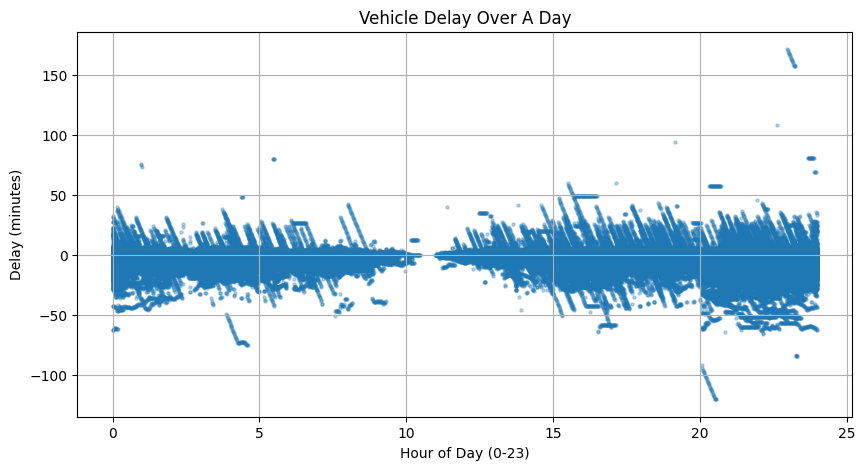

In [127]:

plt.figure(figsize = (10,5))
plt.scatter(df['hour_decimal'], df['delay_minutes'], s=5, alpha = 0.3)
plt.title('Vehicle Delay Over A Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Delay (minutes)')
plt.grid(True)
plt.show()

This scatter plot shows that delays are clustered within 50 minutes.  Around 10 am, delays are relatively contained at around 0 minutes.  But there is a gradual increase in delays reporting from and towards 10 am mark.  The data is more spread out after 10 am.  

A histogram will help us see what might be the most common delay time is for vehicles.

Text(0.5, 1.0, 'Distribution of Bus Delays')

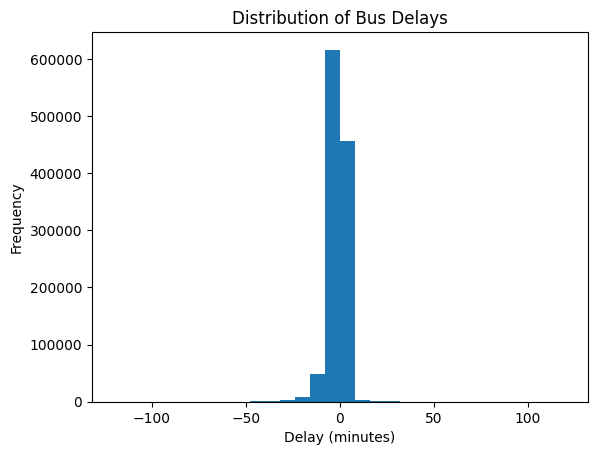

In [128]:
df['delay_minutes'].plot(kind='hist', bins=30, range=(-120, 120))
plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Bus Delays")


From the histogram, we can see that the distribution of data is mainly around 0 meaning most of the buses are generally not delayed or early.  There are only some extreme reporting of data going + or - 30 minutes.  So it is probably safe to discard these bad datas as it won't actually have much impact in the end.

Let's actually see how much data will be removed if we cut of delay outliers.

In [129]:
# let's cut off by 30 mins delay or early
cutoff_delay = 30
outliers = df[(df['delay_minutes'] < -cutoff_delay) | (df['delay_minutes'] > cutoff_delay)]
print(outliers['delay_minutes'].describe())
percent_outliers = len(outliers) / len(df) * 100
print(f'{percent_outliers:.2f} % of vehicles are {cutoff_delay} minutes early or late')


count   3683.00
mean     -30.55
std       31.65
min     -120.25
25%      -44.08
50%      -36.18
75%      -31.87
max      171.18
Name: delay_minutes, dtype: float64
0.32 % of vehicles are 30 minutes early or late


We can apply the cut off and let's see how it impacts our data.

In [130]:
print("Before cleaning delays")
print(df['delay_minutes'].describe())
before_delay_cut_df = df.copy()
df = df[(df['delay_minutes'] >= -cutoff_delay) & (df['delay_minutes'] <= cutoff_delay)]

Before cleaning delays
count   1141797.00
mean         -1.76
std           4.49
min        -120.25
25%          -2.75
50%          -0.60
75%           0.00
max         171.18
Name: delay_minutes, dtype: float64


After cleaning delays:

In [131]:
print("After cleaning delays")
print(df['delay_minutes'].describe())
before_cut = len(before_delay_cut_df)
print(f"{before_cut - len(df)} out of {len(df)} rows removed from delay cleaning.")
print(f"{(before_cut - len(df)) / before_cut * 100:.2f}% of data removed.")
print(f"std for delay dropped from {before_delay_cut_df['delay_minutes'].std():.2f} to {df['delay_minutes'].std():.2f}")

After cleaning delays
count   1138114.00
mean         -1.66
std           3.78
min         -30.00
25%          -2.72
50%          -0.60
75%           0.00
max          30.00
Name: delay_minutes, dtype: float64
3683 out of 1138114 rows removed from delay cleaning.
0.32% of data removed.
std for delay dropped from 4.49 to 3.78


## Load Percentage

Let's start off by generating histogram to see data frequency

Text(0.5, 1.0, 'Distribution of Load Percentage')

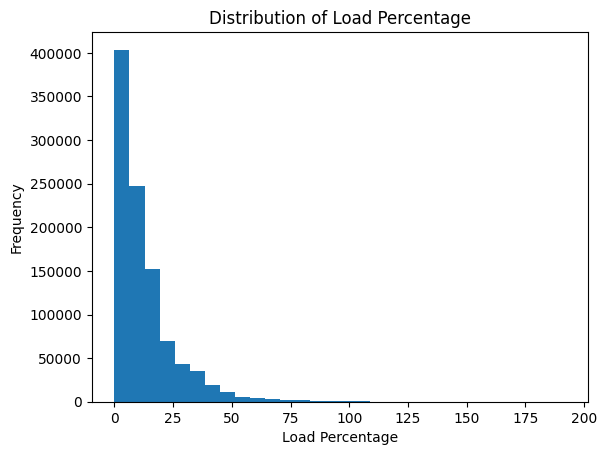

In [132]:
df['loadPercentage'].plot(kind='hist', bins=30)
plt.xlabel("Load Percentage")
plt.ylabel("Frequency")
plt.title("Distribution of Load Percentage")


This shows that most data reports below 25% load percentage.
There are some data that reports load percentage over 100%.

Since very low amount of data reports over 100 load percentage and it doesn't make sense that load percentage goes over 100, we've chosen to drop anything over 100 load percentage since it most likely comes from erroneous collection of data.

In [133]:
before_cut_df = df.copy()
df = df[~(df['loadPercentage'] > 100)].copy()

In [134]:
print("Before cleaning load percentage:")
print(before_cut_df['loadPercentage'].describe())

# Remove load percentage over 100 that is not null
print("After cleaning load percentage:")
print(df['loadPercentage'].describe())
print(f'\n{(len(before_cut_df) - len(df))} out of {len(before_cut_df)} rows removed from load percentage cleaning. ({(len(before_cut_df) - len(df)) / len(before_cut_df) * 100:.2f}% of data)')
len(df)

Before cleaning load percentage:
count   1001057.00
mean         12.11
std          13.81
min           0.00
25%           3.00
50%           8.00
75%          17.00
max         192.00
Name: loadPercentage, dtype: float64
After cleaning load percentage:
count   999852.00
mean        11.98
std         13.30
min          0.00
25%          3.00
50%          8.00
75%         17.00
max        100.00
Name: loadPercentage, dtype: float64

1205 out of 1138114 rows removed from load percentage cleaning. (0.11% of data)


1136909

# Insightful Questions and Conclusion

Now that we've finished some data cleaning, we can start more in depth analysis of the data to create better insights on public transportation system throughout the day.

### Does rush hour impact on time performance

The first obvious thing to look at is what is the impact of bus delays during rush hour.

We will define rush hour the time period at 7-9 AM and 4-6 PM on Weekdays.

In [135]:
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekday = df['day'].isin(weekday_names)

morning_rush = (df['hour'] >= 7) & (df['hour'] <9)
evening_rush = (df['hour'] >= 16) & (df['hour'] <18)

df['is_rush_hour'] = weekday & (morning_rush | evening_rush)

df['is_rush_hour'].describe()

count     1136909
unique          2
top         False
freq      1017719
Name: is_rush_hour, dtype: object

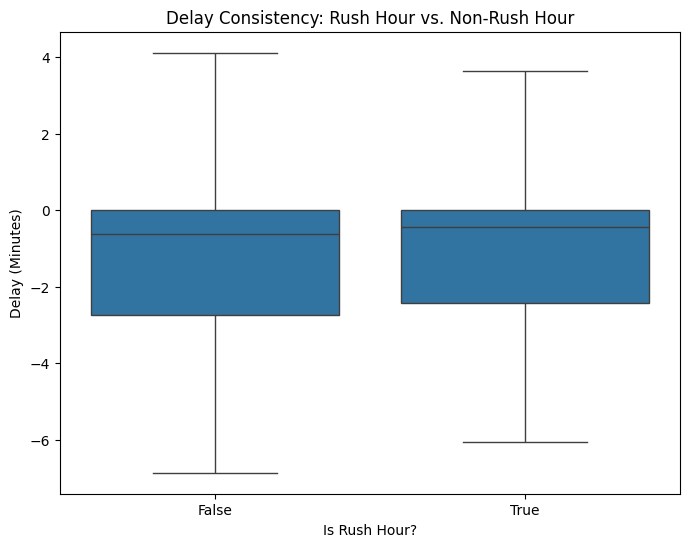

In [136]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='is_rush_hour', y='delay_minutes', showfliers=False) 
plt.title('Delay Consistency: Rush Hour vs. Non-Rush Hour')
plt.ylabel('Delay (Minutes)')
plt.xlabel('Is Rush Hour?')
plt.show()

In [137]:
rush_hour_stats = df.groupby('is_rush_hour')['delay_minutes'].agg(['mean', 'std', 'count'])
rush_hour_stats.index = ['Non-Rush Hour', 'Rush Hour']

print(rush_hour_stats)

std_dev_rush_hour = rush_hour_stats.loc['Rush Hour', 'std']
std_dev_non_rush_hour = rush_hour_stats.loc['Non-Rush Hour', 'std']

               mean  std    count
Non-Rush Hour -1.68 3.80  1017719
Rush Hour     -1.47 3.56   119190


#### Counter intuitive results

From this, it is surprising to see that the average delay during rush hour and rush hour. The average delay is even less during rush hour which is contradictory with original assumptions.

What we can conclude from this is that Trimet actually performs well during rush hour.  The reason for this might be that buses are expected to be later during rush hour and are given more time during this time.  The delay only captures when buses fails to meet their scheduled arrival so perhaps because they are given more time during rush hour, they are on time more.

Another possible reason would be that there are more buses running during rush hour.  This would obviously help cut down delays for buses as they will have to pick up and drop off less people per stop.

### What is the most congested hour

In [ ]:
hourly_congestion = df.groupby('hour')['inCongestion'].mean() * 100

most_congested_hour = hourly_congestion.idxmax()

print(f"The hour wihth the most congestion is : {most_congested_hour}:00")
print(f"At this time, {hourly_congestion.max():.1f}% of vehicles report being in congestion.")

print(hourly_congestion.sort_values(ascending=False).head(5))

The hour wihth the most congestion is : 18:00
At this time, 1.1% of vehicles report being in congestion.
hour
18   1.13
16   1.05
7    1.01
6    0.95
17   0.85
Name: inCongestion, dtype: object


6pm is the time where most vehicles reported inCongestion which is what is expected.  The next following is 4pm and 7 and 6 am which is actually rush hour.  However, only very little vehicle reported inCongestion during this time.

### How does Congestion impact on time performance.

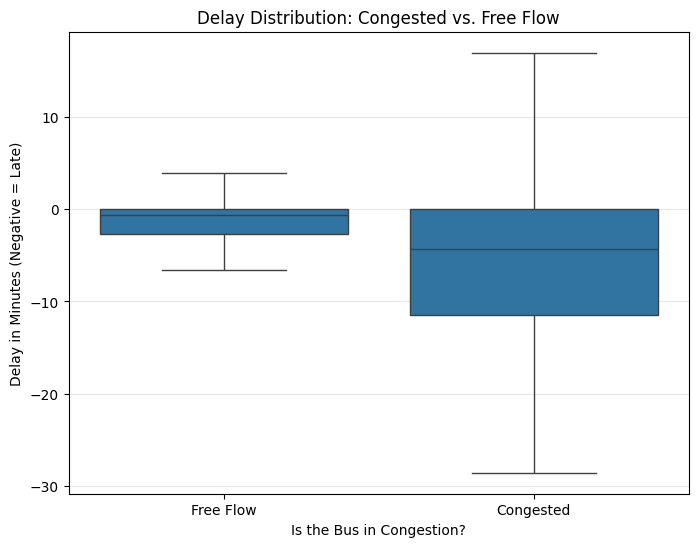

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='inCongestion', y='delay_minutes', showfliers=False)

plt.title('Delay Distribution: Congested vs. Free Flow')
plt.xlabel('Is the Bus in Congestion?')
plt.ylabel('Delay in Minutes (Negative = Late)')
plt.xticks([0, 1], ['Free Flow', 'Congested'])
plt.grid(axis='y', alpha=0.3)
plt.show()

### What route is most likely to be delayed?

In [ ]:
route_performance = df.groupby('routeNumber')['delay_minutes'].agg(['mean','std', 'count'])
print(route_performance.sort_values(by='mean', ascending=True).head(5))
print(route_performance.sort_values(by='mean', ascending=False).head(5))

             mean  std  count
routeNumber                  
293         -7.46 4.15    156
32          -3.80 4.81   4107
12          -2.74 4.77  32836
1           -2.69 3.20    461
15          -2.68 4.65  34325
             mean  std  count
routeNumber                  
55           0.39 1.94    113
63          -0.06 5.00   1034
58          -0.14 3.15   3736
56          -0.27 2.45   9410
67          -0.29 1.52   2728


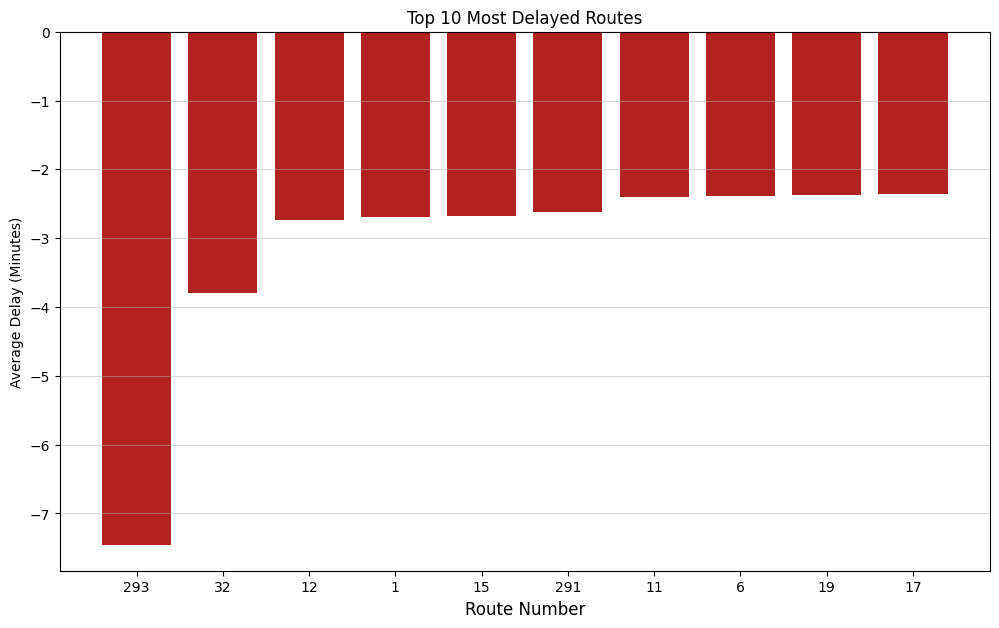

In [ ]:
# prepare for visualization resetting index
worst_route_mean = route_performance.sort_values(by='mean').head(10).reset_index()

plt.figure(figsize=(12,7))
plt.bar(worst_route_mean['routeNumber'].astype(str), worst_route_mean['mean'], color='firebrick')
plt.title('Top 10 Most Delayed Routes')
plt.xlabel('Route Number', fontsize=12)
plt.ylabel('Average Delay (Minutes)')
plt.grid(axis='y', alpha=0.5)
plt.show()


### What routes arrives Earlier than planned

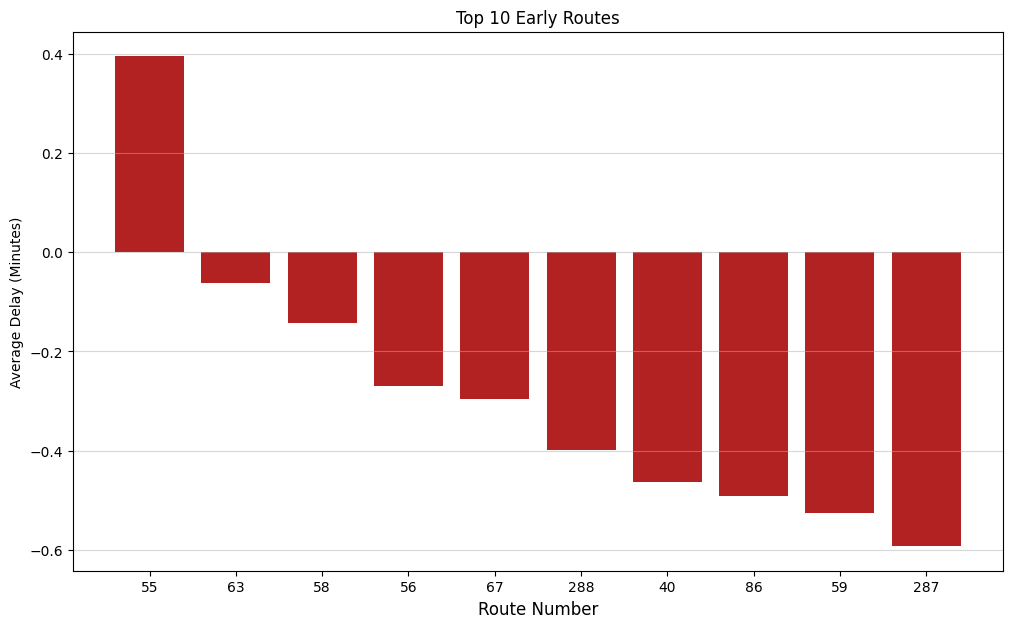

In [ ]:
# prepare for visualization resetting index
best_route_mean= route_performance.sort_values(by='mean', ascending=False).head(10).reset_index()

plt.figure(figsize=(12,7))
plt.bar(best_route_mean['routeNumber'].astype(str),best_route_mean['mean'], color='firebrick')
plt.title('Top 10 Early Routes')
plt.xlabel('Route Number', fontsize=12)
plt.ylabel('Average Delay (Minutes)')
plt.grid(axis='y', alpha=0.5)
plt.show()

In [ ]:
# Filter out the best and worst from dataframe
worst_route = route_performance['mean'].idxmin()
best_route = route_performance['mean'].idxmax()

df_route_performance = df[df['routeNumber'].isin([worst_route,best_route])].copy()


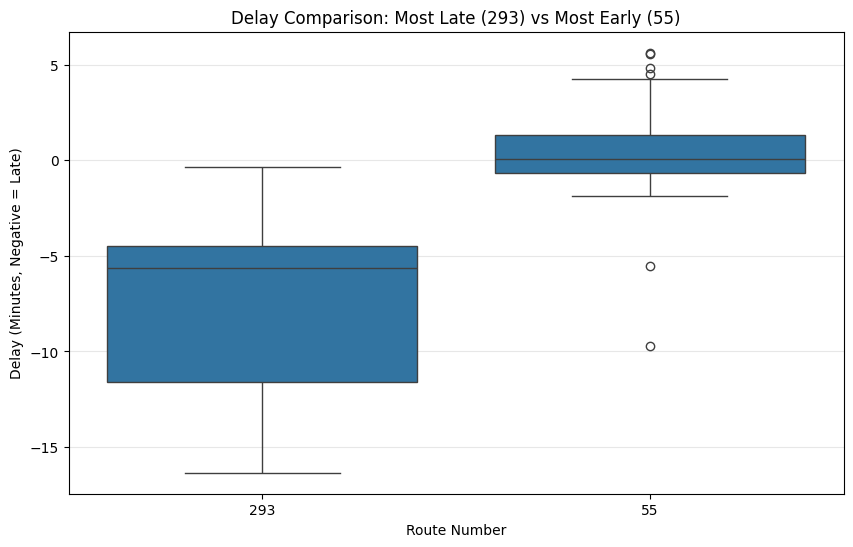

In [ ]:
df['routeLabel'] = df['routeNumber'].astype(str)

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='routeLabel',
    y='delay_minutes',
    order=[str(worst_route), str(best_route)]
)

plt.title(f'Delay Comparison: Most Late ({worst_route}) vs Most Early ({best_route})')
plt.xlabel('Route Number')
plt.ylabel('Delay (Minutes, Negative = Late)')
plt.grid(axis='y', alpha = 0.3)


In [ ]:
# Extract routes as dataframe
df_best_route = df[df['routeNumber'] == best_route].copy()
df_worst_route = df[df['routeNumber'] == worst_route].copy()
print(f"Subtypes found: {df_best_route ['routeSubType'].unique()}")
print(f"Subtypes found: {df_worst_route ['routeSubType'].unique()}")
print(df_best_route .sort_values(by='delay_minutes', ascending=False)[['delay_minutes', 'hour', 'day']].head(5))
print(df_worst_route .sort_values(by='delay_minutes', ascending=True)[['delay_minutes', 'hour', 'day']].head(5))

Subtypes found: ['Bus']
Subtypes found: ['Bus']
         delay_minutes  hour       day
1411298           5.63    15  Thursday
1410835           5.58    15  Thursday
1411761           4.82    15  Thursday
1410373           4.52    14  Thursday
1412223           4.27    15  Thursday
         delay_minutes  hour        day
1254447         -16.35     8  Wednesday
566941          -15.72     8     Monday
566931          -15.68     8     Monday
1254385         -15.67     8  Wednesday
566951          -15.60     8     Monday


### Conclusion and Reflection

After using more graphs to answer some interesting questions there are some elements that were very surprising that came up.

We really thought that rush hour in the morning and evening will have more delays and we wanted to see that.  After creating the boxplot the result was actually against what we thought would happen.  At first it was a bit underwhelming as we expected to uncover something that would be novel and be useful.

However after a brief discussion with Mike, this is indeed not a bad thing and it doesn't mean this project is a failure.  This is a good result.  It shows that Trimet is actually doing pretty good with their planning.  Their estimates of delay during rush hour is very good and this is great because a good on time estimate is really important when it is very busy.  So perhaps Trimet really deserve a better recognition for their service and this project actually shows that it does.

### Future Work

We are pretty satisfied with our work.  We worked with available api and collected data as best as we could.  But there are a lot of future area work that is really promissing.

One thing that I always wanted to do is work with someone who knows a bit more about this data collection system.  Right now we're not really sure how any of these data is recorded or how accurate it is.  I tried to connect with people on LinkedIn to possibly collaborate on this but there is no luck yet so far.  In the future, the hope is that I could connect with someone who knows a bit more about how this api works and can tell me why there are weird data like loadPercentage, delay minutes over 2 hours.  By collaborating with them, we might even be able to improve the api.

Another thing that I was concerned about is that we didn't collect much data.  We have approximately 2 full weeks of data but I still feel it is not enough and our data collection was not constant.  Maybe if we had a dedicated virtual machine collecting data for us 24/7 that would really be more relaible.  It would be great to have a month worth of data.  Perhaps even during a holiday event which we can compare and tell a story of how performance changes.  

Overall this was a fun project.  I was very enthusiastic at the beggining of the project of how much data I could be working with and through out the project it was very fun having to dig into the data and investigate why data is in a certain way.  This project shows me that data can tell a lot of story.  It is very powerful and I now see why many tech companies are always hungry to collect data from you.